In [1]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from src.matplotlib import Styles
from src.service import ExperimentService
from src.config import PLOTS_DIR

plt.style.use(Styles.CMR10.value)
experiment_service = ExperimentService()

2025-09-26 13:57:23.612 | INFO     | src.config:<module>:28 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-09-26 13:57:23.613 | INFO     | src.config:<module>:67 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-09-26 13:57:23.613 | INFO     | src.config:<module>:68 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data
2025-09-26 13:57:23.614 | INFO     | src.matplotlib.color:<module>:103 - Accessible color palette inspired by https://github.com/mpetroff/accessible-color-cycles.


In [ ]:
def resolve_name(name: str) -> str:
    exceptions = ["Loss", "duration (sec)"]

    return f"TEST: {name}" if name not in exceptions else name


def plot_hyperparameter(
    metric: str,
    hyperparam: str,
    df: pl.DataFrame,
    history: pl.DataFrame,
    subtitle: str = None,
    save: bool = False,
):
    metric_name = resolve_name(metric)
    sns.lineplot(
        data=(
            df.select(["run_id", hyperparam])
            .join(
                history.filter(pl.col("metric") == metric_name),
                on="run_id",
            )
            .to_pandas()
        ),
        x="step",
        y="value",
        hue=hyperparam,
    )

    if subtitle:
        title = f"Test {metric} over Epochs: {subtitle}"
    else:
        title = f"Test {metric} over Epochs"
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(f"Test {metric}")
    plt.legend(title=hyperparam.title())

    if save:
        plt.savefig(
            PLOTS_DIR / f"{metric}_{hyperparam}_directed_vs_undirected.png",
            dpi=300,
            format="png",
            bbox_inches="tight",
        )


def plot_metric_over_epochs(metric: str, history: pl.DataFrame):
    metric_name = resolve_name(metric)

    sns.lineplot(
        data=history.filter(pl.col("metric") == metric_name).to_pandas(),
        x="step",
        y="value",
    )
    plt.title(f"{metric} over Epochs for Dir vs Undir Experiment (50 Trials)")
    plt.xlabel("Epochs")
    plt.ylabel(metric.title())

## Hidden Size

In [3]:
hidden_size_df = experiment_service.get_experiment_runs_as_df(experiment_name="Hidden Size")
hidden_size_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool
"""13e4acec34ca489fb7f8d5e6b584e2…",64.903,0.603891,0.878196,0.954217,0.913706,0.804112,1.0,0.891422,0.811792,0.882572,0.788587,0.726525,1.0,0.841604,0.872112,0.938384,0.881817,0.796321,1.0,0.886613,500,8,0.5,"""cuda""",8,true,true,true
"""9910b86ed28c487096907fc6c2740e…",60.186,0.600584,0.887957,0.960795,0.931594,0.816936,1.0,0.899246,0.812197,0.878294,0.788237,0.726952,1.0,0.84189,0.873487,0.942706,0.903456,0.798068,1.0,0.887695,500,8,0.5,"""cuda""",8,true,true,true
"""1272cfdc52de4e4fab31298e7b95b4…",59.982,0.598807,0.879709,0.957411,0.924785,0.806073,1.0,0.892625,0.811388,0.874068,0.776619,0.726098,1.0,0.841317,0.860011,0.931664,0.874668,0.781263,1.0,0.877201,500,8,0.5,"""cuda""",8,true,true,true
"""683b8dec7f5f412f927aca89d685d7…",60.231,0.5975,0.866236,0.957084,0.928324,0.788937,1.0,0.882018,0.803219,0.871553,0.773198,0.717586,1.0,0.835575,0.865237,0.947658,0.906183,0.787695,1.0,0.881241,500,8,0.5,"""cuda""",8,true,true,true
"""af09fe297908480ab545335e0ef5c5…",59.844,0.602816,0.87366,0.954249,0.914357,0.798288,1.0,0.887831,0.81252,0.877058,0.785663,0.727294,1.0,0.84212,0.863586,0.944853,0.901362,0.785653,1.0,0.879961,500,8,0.5,"""cuda""",8,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""80a10e26b36040c3a563fe4fe08aab…",51.759,0.602361,0.887957,0.95737,0.923382,0.816936,1.0,0.899246,0.817535,0.883292,0.792425,0.732638,1.0,0.845691,0.874312,0.946928,0.903244,0.799121,1.0,0.888346,500,2,0.5,"""cuda""",8,true,true,true
"""ad9ecb71ca80493eaa68fc66ee52b0…",52.884,0.613192,0.882321,0.887673,0.789847,0.809481,1.0,0.894711,0.821093,0.828091,0.731319,0.736478,1.0,0.848244,0.876238,0.883812,0.793525,0.801587,1.0,0.889868,500,2,0.5,"""cuda""",8,true,true,true
"""b3f13c9a03994ddcac059d0728e35b…",53.095,0.615982,0.890569,0.894732,0.845518,0.820438,1.0,0.901363,0.814704,0.81824,0.737324,0.729612,1.0,0.843671,0.874037,0.877712,0.819079,0.79877,1.0,0.888129,500,2,0.5,"""cuda""",8,true,true,true


In [25]:
overall_history = experiment_service.all_runs_history(experiment_name="Hidden Size")
overall_history

Fetching Run Histories: 100%|██████████| 51/51 [00:24<00:00,  2.11run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""dc4111ea715e4f65bb8a97c5fb3e5b…",1758857019693,1,"""Loss""",0.72962
"""dc4111ea715e4f65bb8a97c5fb3e5b…",1758857019818,2,"""Loss""",0.727314
"""dc4111ea715e4f65bb8a97c5fb3e5b…",1758857019931,3,"""Loss""",0.732603
"""dc4111ea715e4f65bb8a97c5fb3e5b…",1758857020043,4,"""Loss""",0.724323
"""dc4111ea715e4f65bb8a97c5fb3e5b…",1758857020146,5,"""Loss""",0.71777
…,…,…,…,…
"""06416dffed61404ebc64ac6ca5fde5…",1758851835849,496,"""VAL: F1 Score""",0.887695
"""06416dffed61404ebc64ac6ca5fde5…",1758851835943,497,"""VAL: F1 Score""",0.887695
"""06416dffed61404ebc64ac6ca5fde5…",1758851836037,498,"""VAL: F1 Score""",0.887695


<Axes: xlabel='step', ylabel='value'>

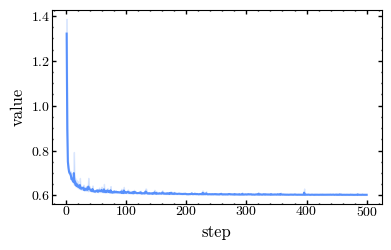

In [6]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "Loss").to_pandas(),
    x="step",
    y="value",
)

<Axes: xlabel='step', ylabel='value'>

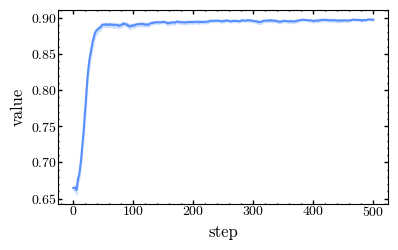

In [7]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "TEST: F1 Score").to_pandas(),
    x="step",
    y="value",
)

Text(0.5, 1.0, 'Mean Test ROC-AUC by Hidden Dimension')

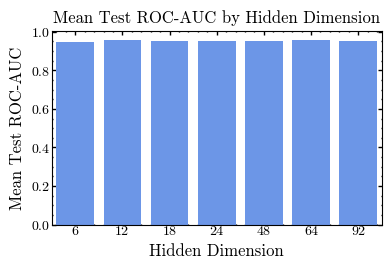

In [8]:
sns.barplot(
    data=hidden_size_df.group_by("hidden_dim").agg(pl.col("TEST: ROC-AUC").mean()).to_pandas(),
    x="hidden_dim",
    y="TEST: ROC-AUC",
)
plt.xlabel("Hidden Dimension")
plt.ylabel("Mean Test ROC-AUC")
plt.title("Mean Test ROC-AUC by Hidden Dimension")

## Directed vs Undirected

In [5]:
dir_vs_undir_df = experiment_service.get_experiment_runs_as_df(experiment_name="Dir vs Undir")
dir_vs_undir_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool
"""8401086e0b094cb39fadefb8d795bc…",72.508,0.600837,0.888644,0.958774,0.926778,0.817855,1.0,0.899802,0.822064,0.877175,0.776814,0.737533,1.0,0.848943,0.878988,0.944309,0.897223,0.805137,1.0,0.892051,500,24,0.5,"""cuda""",8,true,true,true
"""d5a201fbda3c4db9bd8aad235d335a…",72.616,0.603964,0.886857,0.957734,0.926358,0.815471,1.0,0.898357,0.819233,0.87635,0.785362,0.734466,1.0,0.846907,0.867162,0.936341,0.885874,0.790091,1.0,0.882739,500,24,0.5,"""cuda""",8,true,true,true
"""6c6e7d6f3f3b4453af03a8712a9556…",72.729,0.601327,0.890982,0.957767,0.925024,0.820993,1.0,0.901698,0.816888,0.877063,0.77402,0.731944,1.0,0.845228,0.872662,0.947616,0.90825,0.797019,1.0,0.887046,500,24,0.5,"""cuda""",8,true,true,true
"""561d100ded7d4cdf94ffab837c2748…",72.562,0.601665,0.889469,0.956583,0.927326,0.819247,0.99945,0.900421,0.818424,0.877573,0.782196,0.733816,0.999353,0.846243,0.872662,0.944811,0.90823,0.79728,0.99945,0.88699,500,24,0.5,"""cuda""",8,true,true,true
"""18f94038db82432daa4acd6ff01b9f…",72.96,0.59965,0.891394,0.95867,0.922868,0.82155,1.0,0.902034,0.821013,0.876919,0.786928,0.736391,1.0,0.848185,0.876788,0.940474,0.88591,0.802295,1.0,0.890304,500,24,0.5,"""cuda""",8,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""738efbb9d5a44055b591cdb4889dee…",88.378,0.568283,0.863143,0.972719,0.967193,0.790115,0.989002,0.878442,0.786639,0.903948,0.862958,0.703444,0.991103,0.822858,0.852723,0.963879,0.951321,0.775038,0.993949,0.870948,500,24,0.5,"""cuda""",8,true,false,true
"""265b717922cb43b8acc9d3d016d043…",90.438,0.563621,0.800385,0.973763,0.967127,0.715186,0.99835,0.833372,0.743489,0.912467,0.87033,0.661101,0.999191,0.795723,0.785754,0.963431,0.949549,0.700193,0.99945,0.823476,500,24,0.5,"""cuda""",8,true,false,true
"""c133506e79c849e68edd4aa594ff5a…",88.876,0.56118,0.870085,0.953764,0.956012,0.815814,0.956008,0.880365,0.803017,0.894247,0.86192,0.729748,0.962472,0.830107,0.85011,0.938249,0.937332,0.791038,0.951595,0.86392,500,24,0.5,"""cuda""",8,true,false,true


In [6]:
overall_history_dir_vs_undir = experiment_service.all_runs_history(experiment_name="Dir vs Undir")
overall_history_dir_vs_undir

Fetching Run Histories: 100%|██████████| 100/100 [00:51<00:00,  1.94run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""8401086e0b094cb39fadefb8d795bc…",1758776871063,1,"""Loss""",0.937607
"""8401086e0b094cb39fadefb8d795bc…",1758776871209,2,"""Loss""",0.779202
"""8401086e0b094cb39fadefb8d795bc…",1758776871351,3,"""Loss""",0.735573
"""8401086e0b094cb39fadefb8d795bc…",1758776871488,4,"""Loss""",0.701152
"""8401086e0b094cb39fadefb8d795bc…",1758776871626,5,"""Loss""",0.702109
…,…,…,…,…
"""25b7a4780bc4414faf825ea730717e…",1758766519280,496,"""VAL: F1 Score""",0.873868
"""25b7a4780bc4414faf825ea730717e…",1758766519441,497,"""VAL: F1 Score""",0.874819
"""25b7a4780bc4414faf825ea730717e…",1758766519601,498,"""VAL: F1 Score""",0.874713


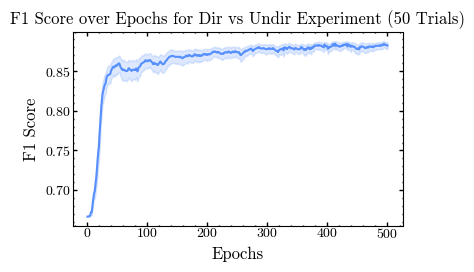

In [7]:
plot_metric_over_epochs("F1 Score", overall_history_dir_vs_undir)

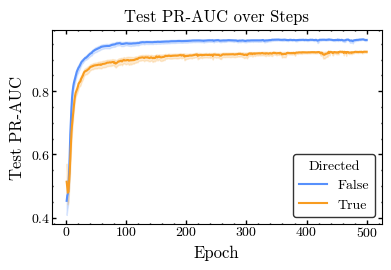

In [8]:
plot_hyperparameter("PR-AUC", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)

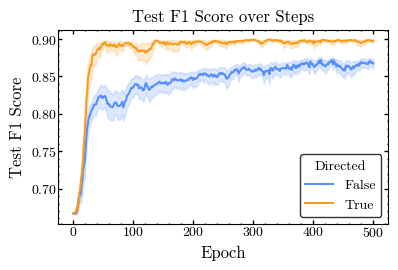

In [9]:
plot_hyperparameter("F1 Score", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)

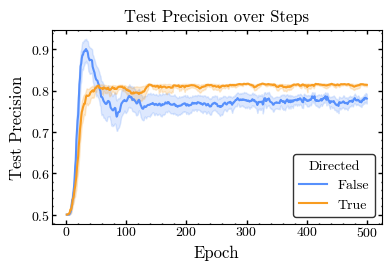

In [10]:
plot_hyperparameter("Precision", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)

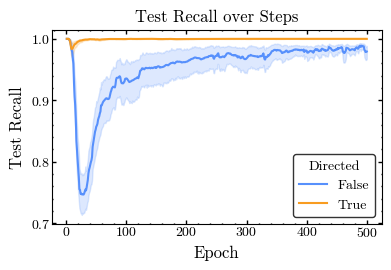

In [11]:
plot_hyperparameter("Recall", "directed", dir_vs_undir_df, overall_history_dir_vs_undir)

## GraphSAGE vs GCN

In [14]:
gsage_vs_gcn_df = experiment_service.get_experiment_runs_as_df(experiment_name="GraphSAGE vs GCN")
gsage_vs_gcn_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool
"""602893bfdcf14c608df743182c877c…",73.918,0.604266,0.889332,0.952023,0.911858,0.818775,1.0,0.900359,0.819557,0.874826,0.788938,0.734815,1.0,0.847139,0.866612,0.936933,0.889618,0.789405,1.0,0.88231,500,24,0.5,"""cuda""",8,true,true,true
"""043a26aa23534e71a85b918ddc643d…",71.833,0.602931,0.88342,0.958126,0.929045,0.810925,1.0,0.895592,0.823843,0.883834,0.789533,0.739474,1.0,0.850227,0.878988,0.940813,0.893838,0.805137,1.0,0.892051,500,24,0.5,"""cuda""",8,true,true,true
"""ebf9cac7fb404f7cac6ef19d2c917c…",71.441,0.605025,0.876684,0.957113,0.92258,0.802161,1.0,0.890222,0.802248,0.869274,0.773373,0.716587,1.0,0.834898,0.869637,0.943249,0.896177,0.793194,1.0,0.884672,500,24,0.5,"""cuda""",8,true,true,true
"""a72b86e110ff4c189f2ee9b2809e95…",71.334,0.602459,0.891669,0.959377,0.930769,0.821921,1.0,0.902258,0.825057,0.877827,0.786734,0.740803,1.0,0.851105,0.867712,0.936724,0.890985,0.790779,1.0,0.883167,500,24,0.5,"""cuda""",8,true,true,true
"""d6aa1175534042a8952fde933e0f45…",70.967,0.601769,0.88672,0.957416,0.928385,0.815288,1.0,0.898246,0.816402,0.875964,0.797414,0.731425,1.0,0.844882,0.880088,0.945604,0.901467,0.806566,1.0,0.892927,500,24,0.5,"""cuda""",8,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""191c2d1d36024d8b9133c3c372b46d…",74.436,0.606025,0.875722,0.954637,0.921783,0.800925,1.0,0.88946,0.810336,0.875103,0.777212,0.724991,1.0,0.840574,0.875688,0.947267,0.900881,0.800881,1.0,0.889432,500,24,0.5,"""cuda""",8,true,true,true
"""e4f04524f08249e39e608dc822e882…",73.518,0.602647,0.862936,0.932974,0.886213,0.784851,1.0,0.879458,0.814785,0.857775,0.759529,0.729698,1.0,0.843729,0.855061,0.923955,0.869671,0.775267,1.0,0.873409,500,24,0.5,"""cuda""",8,true,true,true
"""5d3d532957714d828eecd0432232f5…",75.868,0.598728,0.890157,0.963348,0.936848,0.820027,0.999725,0.901004,0.815513,0.87748,0.777161,0.730474,1.0,0.844247,0.878438,0.94631,0.901085,0.804425,1.0,0.891614,500,24,0.5,"""cuda""",8,true,true,true


In [15]:
overall_history_gsage_vs_gcn = experiment_service.all_runs_history(experiment_name="GraphSAGE vs GCN")
overall_history_gsage_vs_gcn

Fetching Run Histories: 100%|██████████| 120/120 [01:00<00:00,  1.99run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""602893bfdcf14c608df743182c877c…",1758766233981,1,"""Loss""",1.014181
"""602893bfdcf14c608df743182c877c…",1758766234124,2,"""Loss""",0.783743
"""602893bfdcf14c608df743182c877c…",1758766234268,3,"""Loss""",0.703719
"""602893bfdcf14c608df743182c877c…",1758766234402,4,"""Loss""",0.670259
"""602893bfdcf14c608df743182c877c…",1758766234540,5,"""Loss""",0.670898
…,…,…,…,…
"""ce57da0ebda4443c984cdf1c667f52…",1758720141353,496,"""VAL: F1 Score""",0.887262
"""ce57da0ebda4443c984cdf1c667f52…",1758720141487,497,"""VAL: F1 Score""",0.887262
"""ce57da0ebda4443c984cdf1c667f52…",1758720141621,498,"""VAL: F1 Score""",0.887046


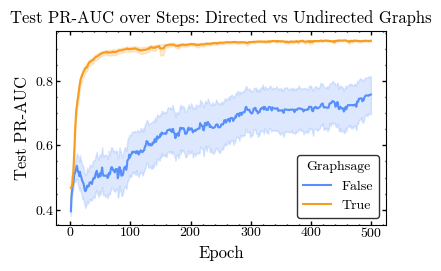

In [6]:
plot_hyperparameter("PR-AUC", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

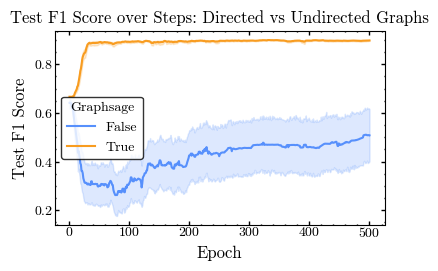

In [7]:
plot_hyperparameter("F1 Score", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

In [50]:

print(f"GraphSAGE has an average TEST: Precision of {gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Precision'].mean():.4f}±{(gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Precision'].std() * 3):.4f}")

GraphSAGE has an average TEST: Precision of 0.8151±0.0338


In [55]:

print(f"GCN has an average TEST: Precision of {gsage_vs_gcn_df.filter(~pl.col('graphsage'))['TEST: Precision'].mean():.4f}±{(gsage_vs_gcn_df.filter(~pl.col('graphsage'))['TEST: Precision'].std() * 3):.4f}")

GCN has an average TEST: Precision of 0.4710±1.1755


GraphSAGE has better F1 performance and a tighter variance than GCN.

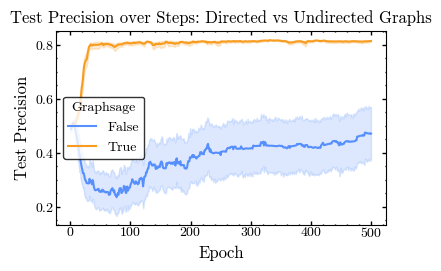

In [32]:
plot_hyperparameter("Precision", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

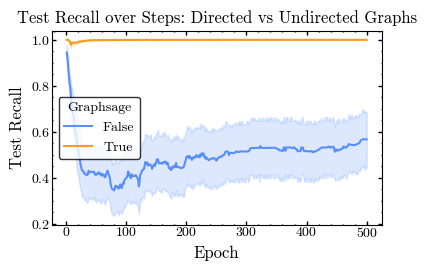

In [33]:
plot_hyperparameter("Recall", "graphsage", gsage_vs_gcn_df, overall_history_gsage_vs_gcn)

In [8]:
print(f"GraphSAGE has an average TEST: Recall of {gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Recall'].mean():.4f}±{(gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Recall'].std() * 3):.4f}")

GraphSAGE has an average TEST: Recall of 0.9998±0.0023


In [9]:
print(f"GCN has an average TEST: Recall of {gsage_vs_gcn_df.filter(~pl.col('graphsage'))['TEST: Recall'].mean():.4f}±{(gsage_vs_gcn_df.filter(pl.col('graphsage'))['TEST: Recall'].std() * 3):.4f}")

GCN has an average TEST: Recall of 0.5669±0.0023


In [18]:
def print_metric(graphsage: bool, metric: str):
    metric_name = resolve_name(metric)

    if graphsage:
        col = pl.col('graphsage')
        model_name = "GraphSAGE"
    else:
        col = ~pl.col('graphsage')
        model_name = "GCN"
    print(f"{model_name} has a {metric_name} of {gsage_vs_gcn_df.filter(col)[metric_name].mean():.3f}±{(gsage_vs_gcn_df.filter(col)[metric_name].std() * 3):.3f}")

In [28]:
print_metric(False, "PR-AUC")

GCN has a TEST: PR-AUC of 0.758±0.703


## Num Layers

In [2]:
num_layers_df = experiment_service.get_experiment_runs_as_df(experiment_name="Num Layers")
num_layers_df

run_id,duration (sec),Loss,TEST: Accuracy,TEST: ROC-AUC,TEST: PR-AUC,TEST: Precision,TEST: Recall,TEST: F1 Score,TRAIN: Accuracy,TRAIN: ROC-AUC,TRAIN: PR-AUC,TRAIN: Precision,TRAIN: Recall,TRAIN: F1 Score,VAL: Accuracy,VAL: ROC-AUC,VAL: PR-AUC,VAL: Precision,VAL: Recall,VAL: F1 Score,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool
"""29bc0c5531b94c34b584c453228034…",293.378,0.617603,0.752131,0.894193,0.912581,0.668566,1.0,0.801366,0.743206,0.824773,0.49574,0.660682,1.0,0.795675,0.749725,0.870799,0.89716,0.666422,1.0,0.799824,500,24,0.5,"""cuda""",64,true,true,true
"""dbec7fcc18d842389dac6f371fc214…",280.307,0.612119,0.5,0.913515,0.854269,0.5,1.0,0.666667,0.5,0.833396,0.744252,0.5,1.0,0.666667,0.5,0.888781,0.81836,0.5,1.0,0.666667,500,24,0.5,"""cuda""",64,true,true,true
"""089564388c4f445a8feb3eb0c65981…",279.939,0.616095,0.88782,0.889393,0.826916,0.816753,1.0,0.899135,0.819476,0.817799,0.728951,0.734728,1.0,0.847081,0.881738,0.880558,0.813578,0.808719,1.0,0.894245,500,24,0.5,"""cuda""",64,true,true,true
"""f78084e70a3341d986131416b42a4f…",279.813,0.613104,0.893181,0.894301,0.912611,0.823969,1.0,0.90349,0.816322,0.817372,0.866137,0.731338,1.0,0.844824,0.878713,0.880988,0.903668,0.804781,1.0,0.891832,500,24,0.5,"""cuda""",64,true,true,true
"""6eda6dd16b6046db808ec0973b9ca2…",279.656,0.610793,0.88782,0.885194,0.788815,0.816753,1.0,0.899135,0.822954,0.822653,0.735707,0.738502,1.0,0.849584,0.873762,0.87046,0.767782,0.798419,1.0,0.887912,500,24,0.5,"""cuda""",64,true,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""c81fd4b331084d9dad58c6997f4666…",47.275,0.607914,0.881771,0.953429,0.913966,0.808761,1.0,0.894271,0.822549,0.876493,0.785673,0.738061,1.0,0.849292,0.879538,0.938241,0.88659,0.805851,1.0,0.892489,500,24,0.5,"""cuda""",2,true,true,true
"""67d0181d5d17429dad32dfb3d5dee1…",45.999,0.601789,0.872835,0.948892,0.907335,0.797238,1.0,0.887181,0.80694,0.865992,0.762242,0.721438,1.0,0.83818,0.866887,0.940139,0.892917,0.789748,1.0,0.882524,500,24,0.5,"""cuda""",2,true,true,true
"""404aa59a0d6c403fafe040549ed86a…",46.378,0.60443,0.889744,0.950499,0.912163,0.819329,1.0,0.900693,0.825057,0.87649,0.77906,0.740803,1.0,0.851105,0.870462,0.929767,0.868125,0.794233,1.0,0.885318,500,24,0.5,"""cuda""",2,true,true,true


In [3]:
overall_history_num_layers = experiment_service.all_runs_history(experiment_name="Num Layers")
overall_history_num_layers

Fetching Run Histories: 100%|██████████| 250/250 [02:04<00:00,  2.01run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""29bc0c5531b94c34b584c453228034…",1758849813151,1,"""Loss""",1.58159
"""29bc0c5531b94c34b584c453228034…",1758849813786,2,"""Loss""",1.227732
"""29bc0c5531b94c34b584c453228034…",1758849814385,3,"""Loss""",0.818559
"""29bc0c5531b94c34b584c453228034…",1758849814958,4,"""Loss""",0.71371
"""29bc0c5531b94c34b584c453228034…",1758849815543,5,"""Loss""",0.756781
…,…,…,…,…
"""173b73a95347479f8d42418d447dad…",1758777494005,496,"""VAL: F1 Score""",0.887695
"""173b73a95347479f8d42418d447dad…",1758777494089,497,"""VAL: F1 Score""",0.88231
"""173b73a95347479f8d42418d447dad…",1758777494173,498,"""VAL: F1 Score""",0.887912


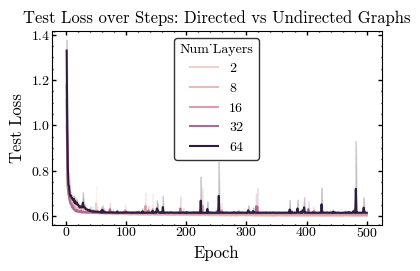

In [11]:
plot_hyperparameter("Loss", "num_layers", num_layers_df, overall_history_num_layers)

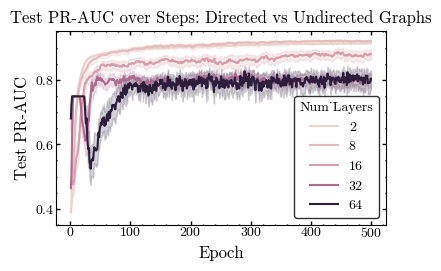

In [13]:
plot_hyperparameter("PR-AUC", "num_layers", num_layers_df, overall_history_num_layers)

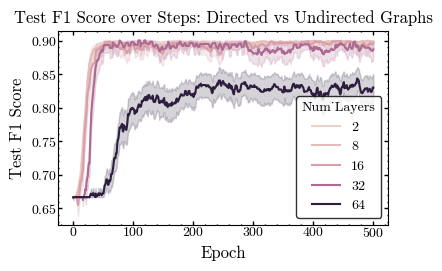

In [22]:
plot_hyperparameter("F1 Score", "num_layers", num_layers_df, overall_history_num_layers)

Text(0.5, 1.0, 'Run Duration by Number of Layers')

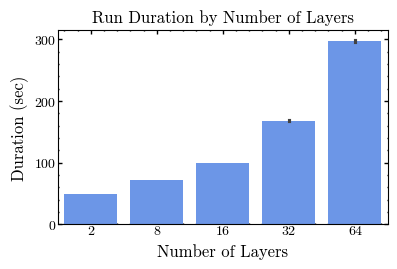

In [21]:
sns.barplot(
    data=num_layers_df,
    x="num_layers",
    y="duration (sec)",
)
plt.xlabel("Number of Layers")
plt.ylabel("Duration (sec)")
plt.title("Run Duration by Number of Layers")

### General Insights

The model was trained using layers 2, 8, 16, and 32 with a learning rate of `0.1`. However, when tried with 64, the model becomes numerically unstable (NaNs in the output). So we trained it with a learning rate of `0.01`, to keep it steady and slower.

The result being is that it is slower to converge and had lower performance compared to layers 2-32.

### PR-AUC

We can see that the more the layers, the lower the performance.

### F1 Score

Has a higher variance with the higher number of layers.


### Training Time

Training time increases quadratically with the number of layers.
